# 🌍 Lab 3: Land Use / Land Cover Classification จังหวัดนครนายก (Colab Fixed + Detailed)



รายวิชา: GE.338 Geographic Data Science

ชื่อ-นามสกุล: สุรนาจ เครือวาท

รหัสนักศึกษา: 6606614847

## 🧭 เป้าหมายของการวิเคราะห์

โจทย์ Lab 3 ต้องการให้ตอบคำถามว่า เมื่อมี training data จำกัด เราควรเลือกวิธีจำแนกแบบใดจึงจะได้ผลดีที่สุด  
นอกจากนี้ยังต้องเปรียบเทียบว่า การใช้เฉพาะ spectral bands กับการเพิ่ม spectral indices จะช่วยให้การจำแนกดีขึ้นหรือไม่  
สุดท้ายต้องประเมินว่าแผนที่ที่ได้ **เชื่อถือได้แค่ไหน** และบริเวณใดคือบริเวณที่โมเดลยังไม่มั่นใจ

สำหรับกรณีศึกษานี้ เราใช้พื้นที่จังหวัดนครนายก ซึ่งมีข้อมูลฝึกสอนแบบ polygon ในไฟล์ `Trainning.shp` และภาพหลายแบนด์จาก Sentinel-2 ในไฟล์ `NKSentinel2.tiff`

ข้อมูล Lab3 : https://drive.google.com/drive/folders/1zxM0jvN86fgjsx9yLsJ5lnb4Fe0X2ksi?usp=sharing

In [1]:
!pip -q install geopandas rasterio shapely fiona pyproj joblib

In [2]:
import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.features import rasterize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 6)
np.set_printoptions(suppress=True)

## 📁 เชื่อม Google Drive และกำหนด path

แก้ `BASE_DIR` ให้ตรงกับโฟลเดอร์ของคุณใน Google Drive  
จากภาพที่คุณส่งมา โครงสร้างคือ `Lab3_Data/NKNY/` และในนั้นมี
- `NKSentinel2.tiff`
- โฟลเดอร์ `Training/` ที่เก็บไฟล์ shapefile ทุกนามสกุล

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_DIR = "/content/drive/MyDrive/Lab3_Data/NKNY"
RASTER_PATH = os.path.join(BASE_DIR, "NKSentinel2.tiff")
TRAIN_SHP = os.path.join(BASE_DIR, "Training", "Trainning.shp")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs_lab3_fixed")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("RASTER_PATH:", RASTER_PATH)
print("TRAIN_SHP  :", TRAIN_SHP)
print("OUTPUT_DIR :", OUTPUT_DIR)
print("Raster exists:", os.path.exists(RASTER_PATH))
print("Shapefile exists:", os.path.exists(TRAIN_SHP))

RASTER_PATH: /content/drive/MyDrive/Lab3_Data/NKNY/NKSentinel2.tiff
TRAIN_SHP  : /content/drive/MyDrive/Lab3_Data/NKNY/Training/Trainning.shp
OUTPUT_DIR : /content/drive/MyDrive/Lab3_Data/NKNY/outputs_lab3_fixed
Raster exists: True
Shapefile exists: True


## ✍️ ขั้นที่ 1: อ่านข้อมูลฝึกสอนและทำความเข้าใจคลาส

ในงานนี้ training samples เป็น polygon ที่นักศึกษาจัดเตรียมเองในพื้นที่นครนายก  
ข้อดีของวิธีนี้คือ polygon แต่ละชิ้นสะท้อนบริบทของพื้นที่จริง ไม่ใช่การยืมจุดตัวอย่างจาก tutorial แบบสำเร็จรูป  
แนวทางนี้สอดคล้องกับเงื่อนไขของ Lab ที่เน้นว่าการเลือก training samples ต้องเหมาะกับพื้นที่ศึกษา ไม่ใช่คัดลอกตัวอย่างจากงานอื่นมาใช้ตรง ๆ fileciteturn2file0

In [5]:
gdf = gpd.read_file(TRAIN_SHP)
print("CRS:", gdf.crs)
print("Columns:", list(gdf.columns))
print("Number of polygons:", len(gdf))
display(gdf.head())

CRS: EPSG:32647
Columns: ['Classcode', 'Classname', 'Classvalue', 'RED', 'GREEN', 'BLUE', 'Count', 'geometry']
Number of polygons: 7


,Classcode,Classname,Classvalue,RED,GREEN,BLUE,Count,geometry
0,None,Buildup,2,204,204,204,11963,"MULTIPOLYGON Z (((711836.595 1545208.355 0, 71..."
1,None,Water,7,0,92,230,34570,"MULTIPOLYGON Z (((714741.347 1546531.261 0, 71..."
2,None,Forest,4,56,168,0,959874,"MULTIPOLYGON Z (((751930.906 1575279.849 0, 75..."
3,None,Fieldcrop,3,85,255,0,54951,"MULTIPOLYGON Z (((708165.807 1544998.309 0, 70..."
4,None,Bareland,1,255,211,127,6787,"MULTIPOLYGON Z (((707535.527 1547405.62 0, 707..."


In [6]:
class_lookup = (
    gdf[["Classname", "Classvalue", "Count"]]
    .groupby(["Classname", "Classvalue"], as_index=False)["Count"]
    .sum()
    .sort_values("Classvalue")
    .reset_index(drop=True)
)

class_lookup["share_percent"] = (class_lookup["Count"] / class_lookup["Count"].sum() * 100).round(2)
display(class_lookup)

class_lookup.to_csv(os.path.join(OUTPUT_DIR, "class_lookup.csv"), index=False)

class_map = dict(zip(class_lookup["Classvalue"], class_lookup["Classname"]))
class_values = class_lookup["Classvalue"].tolist()
class_names = [class_map[v] for v in class_values]

print("Class mapping:", class_map)

,Classname,Classvalue,Count,share_percent
0,Bareland,1,6787,0.63
1,Buildup,2,11963,1.11
2,Fieldcrop,3,54951,5.10
3,Forest,4,959874,89.17
4,Orchard,5,5817,0.54
5,Perennial,6,2471,0.23
6,Water,7,34570,3.21


Class mapping: {1: 'Bareland', 2: 'Buildup', 3: 'Fieldcrop', 4: 'Forest', 5: 'Orchard', 6: 'Perennial', 7: 'Water'}


### 📝 อธิบายเชิงความเรียง

จากข้อมูล training polygon พบว่าเราใช้ทั้งหมด **7 คลาส** ได้แก่ Bareland, Buildup, Fieldcrop, Forest, Orchard, Perennial และ Water  
แม้ในเอกสาร Lab จะเสนอว่าโดยทั่วไป 4–6 คลาสเป็นจำนวนที่เหมาะสม แต่สำหรับกรณีนี้การคงไว้ 7 คลาสมีเหตุผล เพราะสอดคล้องกับงานจำแนกนครนายกเดิมที่แยกคลาสเกษตรและพืชยืนต้นออกจากกันอย่างชัดเจน ทำให้การตีความภูมิทัศน์ของจังหวัดละเอียดขึ้น และสามารถอธิบายความสับสนของโมเดลระหว่างกลุ่มเกษตรหลายประเภทได้ดีกว่าในขั้นวิเคราะห์ผล

## 🛰️ ขั้นที่ 2: ตรวจสอบแบนด์ของภาพ Sentinel-2 และเลือกเฉพาะแบนด์ที่เหมาะสม

ปัญหาสำคัญในเวอร์ชันเดิมคือโค้ดสมมุติว่า 4 แบนด์แรกของ raster คือ Blue, Green, Red และ NIR  
แต่ในไฟล์จริงแบนด์ถูกเรียงตามชื่อจริงของ Sentinel-2 เช่น `B1, B2, B3, B4, ..., B8, B11, B12` รวมถึงแบนด์ประกอบอย่าง `AOT`, `WVP`, `SCL`, `TCI_R`, `TCI_G`, `TCI_B`  
ดังนั้นถ้าใช้ลำดับเดิมจะทำให้การคำนวณ NDVI/NDWI ผิดทันที

ใน notebook นี้ เราจะตรวจสอบชื่อแบนด์ก่อน แล้วเลือกเฉพาะแบนด์ที่มีเหตุผลทางกายภาพต่อการจำแนก ได้แก่
- `B2` = Blue
- `B3` = Green
- `B4` = Red
- `B8` = NIR
- `B11`, `B12` = SWIR

In [7]:
with rasterio.open(RASTER_PATH) as src:
    descriptions = list(src.descriptions)
    profile = src.profile
    transform = src.transform
    crs = src.crs
    height = src.height
    width = src.width
    count = src.count
    dtype = src.dtypes[0]

print("Raster size:", (height, width))
print("Band count :", count)
print("CRS        :", crs)
print("dtype      :", dtype)
print("Descriptions:")
for i, desc in enumerate(descriptions, start=1):
    print(i, "->", desc)

Raster size: (6140, 6376)
Band count : 26
CRS        : EPSG:32647
dtype      : float32
Descriptions:
1 -> B1
2 -> B2
3 -> B3
4 -> B4
5 -> B5
6 -> B6
7 -> B7
8 -> B8
9 -> B8A
10 -> B9
11 -> B11
12 -> B12
13 -> AOT
14 -> WVP
15 -> SCL
16 -> TCI_R
17 -> TCI_G
18 -> TCI_B
19 -> MSK_CLDPRB
20 -> MSK_SNWPRB
21 -> QA10
22 -> QA20
23 -> QA60
24 -> MSK_CLASSI_OPAQUE
25 -> MSK_CLASSI_CIRRUS
26 -> MSK_CLASSI_SNOW_ICE


In [8]:
desired_band_names = ["B2", "B3", "B4", "B8", "B11", "B12"]

name_to_index = {}
for i, desc in enumerate(descriptions, start=1):
    if desc is not None:
        name_to_index[str(desc)] = i

missing_bands = [b for b in desired_band_names if b not in name_to_index]
if missing_bands:
    raise ValueError(f"ไม่พบแบนด์ต่อไปนี้ใน raster: {missing_bands}")

selected_indexes = [name_to_index[b] for b in desired_band_names]
print("Selected band indexes:", selected_indexes)

Selected band indexes: [2, 3, 4, 8, 11, 12]


## 🧪 ขั้นที่ 3: สร้าง label raster จาก polygon และดึงเฉพาะพิกเซลฝึกสอน

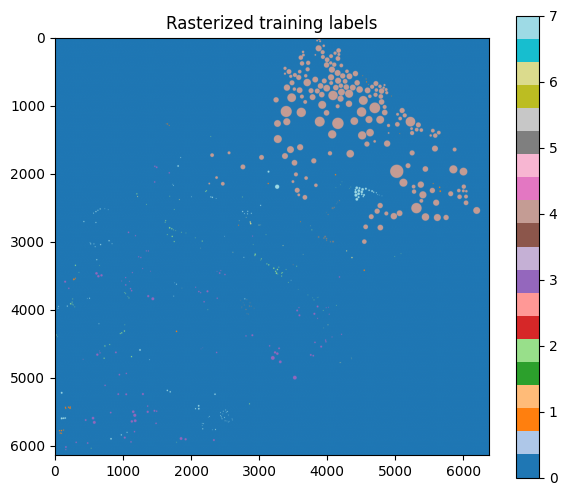

Labeled pixels: 1076337


In [9]:
attribute = "Classvalue"

roi = rasterize(
    [(geom, value) for geom, value in zip(gdf.geometry, gdf[attribute])],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint16"
)

plt.figure(figsize=(7, 6))
plt.imshow(roi, cmap="tab20")
plt.title("Rasterized training labels")
plt.colorbar()
plt.show()

print("Labeled pixels:", int((roi > 0).sum()))

In [10]:
with rasterio.open(RASTER_PATH) as src:
    band_stack = src.read(selected_indexes)

print("Selected stack shape:", band_stack.shape)
print("Selected bands:", desired_band_names)

Selected stack shape: (6, 6140, 6376)
Selected bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']


In [11]:
img_sel = np.transpose(band_stack, (1, 2, 0))
X_base = img_sel[roi > 0].astype("float32")
y = roi[roi > 0].astype("int32")

print("Base feature matrix:", X_base.shape)
print("Label vector:", y.shape)
print("Unique classes:", np.unique(y))

Base feature matrix: (1076337, 6)
Label vector: (1076337,)
Unique classes: [1 2 3 4 5 6 7]


## 🌱 ขั้นที่ 4: สร้าง spectral indices

In [12]:
def safe_divide(a, b, eps=1e-9):
    return a / (b + eps)

def build_features_from_base(X_base, base_band_names):
    """
    X_base shape = (n_samples, n_bands)
    base_band_names = ["B2","B3","B4","B8","B11","B12"]
    """
    df = pd.DataFrame(X_base, columns=base_band_names)

    blue = df["B2"].to_numpy(dtype="float32")
    green = df["B3"].to_numpy(dtype="float32")
    red = df["B4"].to_numpy(dtype="float32")
    nir = df["B8"].to_numpy(dtype="float32")
    swir1 = df["B11"].to_numpy(dtype="float32")
    swir2 = df["B12"].to_numpy(dtype="float32")

    ndvi = safe_divide(nir - red, nir + red)
    ndwi = safe_divide(green - nir, green + nir)
    ndbi = safe_divide(swir1 - nir, swir1 + nir)
    savi = safe_divide((nir - red) * 1.5, nir + red + 0.5)
    nbr = safe_divide(nir - swir2, nir + swir2)

    X_full = np.column_stack([X_base, ndvi, ndwi, ndbi, savi, nbr]).astype("float32")
    feature_names = base_band_names + ["NDVI", "NDWI", "NDBI", "SAVI", "NBR"]
    return X_full, feature_names

X_full, feature_names_full = build_features_from_base(X_base, desired_band_names)

print("Bands only shape   :", X_base.shape)
print("Bands + indices    :", X_full.shape)
print("Feature names full :", feature_names_full)

Bands only shape   : (1076337, 6)
Bands + indices    : (1076337, 11)
Feature names full : ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'SAVI', 'NBR']


## ✂️ ขั้นที่ 5: แบ่งข้อมูล train / validation

ใน notebook นี้ใช้การแบ่งข้อมูลแบบ **สุ่ม 80/20 แบบ stratified**  
วิธีนี้เหมาะกับการสร้าง baseline ที่รันง่ายและเปรียบเทียบโมเดลได้ตรงไปตรงมา

อย่างไรก็ตาม ในทางภูมิสารสนเทศต้องระวังว่า **random split** อาจให้ค่าความแม่นยำสูงเกินจริง  
เพราะพิกเซลที่อยู่ติดกันมักมีความคล้ายกันสูงจาก spatial autocorrelation  
ดังนั้นในส่วนอภิปรายผลควรระบุด้วยว่า ถ้าต้องการประเมินเชิงเข้มงวดกว่าเดิม ควรใช้ spatial cross-validation หรือ block split เพิ่มเติมตามข้อเสนอของ Lab fileciteturn2file0

In [13]:
RANDOM_STATE = 42

Xb_train, Xb_val, y_train, y_val = train_test_split(
    X_base, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

Xf_train, Xf_val, _, _ = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", Xb_train.shape, Xf_train.shape)
print("Valid size:", Xb_val.shape, Xf_val.shape)

Train size: (861069, 6) (861069, 11)
Valid size: (215268, 6) (215268, 11)


In [14]:
def compute_metrics(y_true, y_pred, class_values, class_map):
    cm = confusion_matrix(y_true, y_pred, labels=class_values)
    oa = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, labels=class_values)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=class_values, zero_division=0
    )

    producer = recall
    user = np.divide(np.diag(cm), cm.sum(axis=0), out=np.zeros(len(class_values)), where=cm.sum(axis=0)!=0)

    per_class = pd.DataFrame({
        "Classvalue": class_values,
        "Classname": [class_map[c] for c in class_values],
        "Producer_Accuracy": producer,
        "User_Accuracy": user,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1,
        "Support": support
    })

    return {
        "confusion_matrix": cm,
        "overall_accuracy": oa,
        "kappa": kappa,
        "per_class": per_class
    }

def fit_and_evaluate(model, X_train, y_train, X_val, y_val, class_values, class_map):
    imp = SimpleImputer(strategy="median")
    X_train_imp = imp.fit_transform(X_train)
    X_val_imp = imp.transform(X_val)

    model.fit(X_train_imp, y_train)
    y_pred = model.predict(X_val_imp)

    result = compute_metrics(y_val, y_pred, class_values, class_map)
    result["model"] = model
    result["imputer"] = imp
    result["y_pred"] = y_pred
    return result

## 🤖 ขั้นที่ 6: เปรียบเทียบอัลกอริทึม

In [15]:
rf_grid = [50, 100, 200, 300]
comparison_rows = []
rf_results = {}

for n_trees in rf_grid:
    rf_bands = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    res_b = fit_and_evaluate(rf_bands, Xb_train, y_train, Xb_val, y_val, class_values, class_map)
    comparison_rows.append({
        "Model": "RandomForest",
        "Features": "Bands only",
        "n_estimators": n_trees,
        "OA": res_b["overall_accuracy"],
        "Kappa": res_b["kappa"]
    })
    rf_results[("bands", n_trees)] = res_b

    rf_full = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    res_f = fit_and_evaluate(rf_full, Xf_train, y_train, Xf_val, y_val, class_values, class_map)
    comparison_rows.append({
        "Model": "RandomForest",
        "Features": "Bands + indices",
        "n_estimators": n_trees,
        "OA": res_f["overall_accuracy"],
        "Kappa": res_f["kappa"]
    })
    rf_results[("full", n_trees)] = res_f

hgb_bands = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
res_hgb_b = fit_and_evaluate(hgb_bands, Xb_train, y_train, Xb_val, y_val, class_values, class_map)

hgb_full = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
res_hgb_f = fit_and_evaluate(hgb_full, Xf_train, y_train, Xf_val, y_val, class_values, class_map)

comparison_rows.append({
    "Model": "HistGradientBoosting",
    "Features": "Bands only",
    "n_estimators": np.nan,
    "OA": res_hgb_b["overall_accuracy"],
    "Kappa": res_hgb_b["kappa"]
})

comparison_rows.append({
    "Model": "HistGradientBoosting",
    "Features": "Bands + indices",
    "n_estimators": np.nan,
    "OA": res_hgb_f["overall_accuracy"],
    "Kappa": res_hgb_f["kappa"]
})

comparison_df = pd.DataFrame(comparison_rows).sort_values(["Model", "Features", "n_estimators"], na_position="last")
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_summary.csv"), index=False)
display(comparison_df)

,Model,Features,n_estimators,OA,Kappa
9,HistGradientBoosting,Bands + indices,NaN,0.985906,0.928287
8,HistGradientBoosting,Bands only,NaN,0.984772,0.922516
1,RandomForest,Bands + indices,50.0,0.990347,0.950732
3,RandomForest,Bands + indices,100.0,0.990407,0.951028
5,RandomForest,Bands + indices,200.0,0.990561,0.951815
7,RandomForest,Bands + indices,300.0,0.990533,0.951679
0,RandomForest,Bands only,50.0,0.990793,0.953009
2,RandomForest,Bands only,100.0,0.990886,0.953493
4,RandomForest,Bands only,200.0,0.990969,0.953910
6,RandomForest,Bands only,300.0,0.990914,0.953635


In [16]:
best_row = comparison_df.sort_values(["OA", "Kappa"], ascending=False).iloc[0]

if best_row["Model"] == "RandomForest":
    key = ("full" if best_row["Features"] == "Bands + indices" else "bands", int(best_row["n_estimators"]))
    best_result = rf_results[key]
    best_feature_mode = "full" if best_row["Features"] == "Bands + indices" else "bands"
else:
    best_result = res_hgb_f if best_row["Features"] == "Bands + indices" else res_hgb_b
    best_feature_mode = "full" if best_row["Features"] == "Bands + indices" else "bands"

display(best_row.to_frame().T)
print("Overall Accuracy:", round(best_result["overall_accuracy"], 4))
print("Kappa:", round(best_result["kappa"], 4))
display(best_result["per_class"].round(4))

,Model,Features,n_estimators,OA,Kappa
4,RandomForest,Bands only,200.0,0.990969,0.95391


Overall Accuracy: 0.991
Kappa: 0.9539


,Classvalue,Classname,Producer_Accuracy,User_Accuracy,Precision,Recall,F1_score,Support
0,1,Bareland,0.9314,0.9715,0.9715,0.9314,0.9511,1356
1,2,Buildup,0.9824,0.9878,0.9878,0.9824,0.9851,2392
2,3,Fieldcrop,0.9721,0.9738,0.9738,0.9721,0.9729,10992
3,4,Forest,0.9989,0.9925,0.9925,0.9989,0.9957,191951
4,5,Orchard,0.1918,0.6935,0.6935,0.1918,0.3005,1168
5,6,Perennial,0.2964,0.7989,0.7989,0.2964,0.4324,496
6,7,Water,0.9999,1.0000,1.0000,0.9999,0.9999,6913


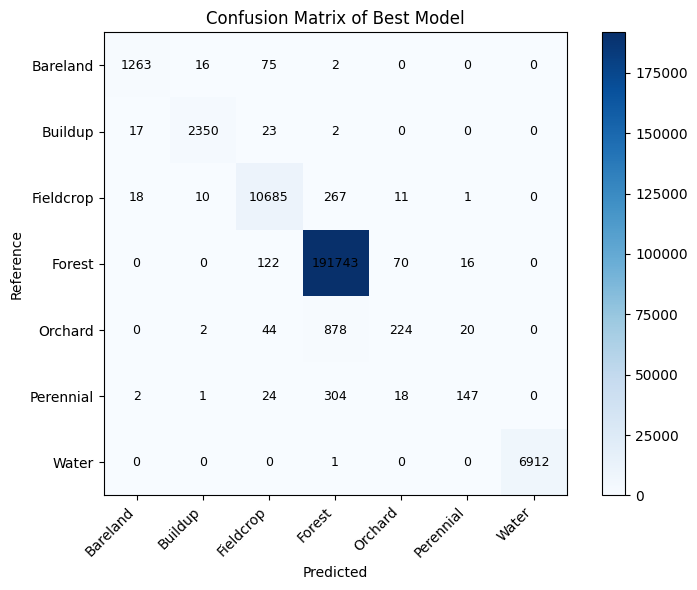

In [17]:
cm = best_result["confusion_matrix"]

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix of Best Model")
plt.xticks(range(len(class_values)), [class_map[c] for c in class_values], rotation=45, ha="right")
plt.yticks(range(len(class_values)), [class_map[c] for c in class_values])
plt.xlabel("Predicted")
plt.ylabel("Reference")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_best_model.png"), dpi=200, bbox_inches="tight")
plt.show()

### 📚 อธิบาย

ช่วงนี้คือหัวใจของ Lab 3 เพราะเป็นการตอบคำถามว่า **โมเดลใดแม่นยำที่สุด** และ **การเพิ่ม indices ช่วยจริงหรือไม่**  
หลักการอ่านผลคือไม่ควรดูเฉพาะ OA อย่างเดียว แต่ต้องดู Kappa และ F1-score รายคลาสประกอบด้วย  
เหตุผลคือบางคลาส เช่น Forest หรือ Fieldcrop อาจมีจำนวนพิกเซลมากกว่าคลาสอื่นมาก ถ้าดูแค่ OA โมเดลอาจดูเหมือนเก่ง ทั้งที่ยังจำแนกคลาสขนาดเล็กอย่าง Bareland หรือ Orchard ได้ไม่ดีนัก

## 🌟 ขั้นที่ 7: วิเคราะห์ Feature Importance ของ Random Forest

In [18]:
rf_full_candidates = comparison_df[(comparison_df["Model"] == "RandomForest") & (comparison_df["Features"] == "Bands + indices")]
rf_best_n = int(rf_full_candidates.sort_values(["OA", "Kappa"], ascending=False).iloc[0]["n_estimators"])
rf_best_full = rf_results[("full", rf_best_n)]

rf_best_model = rf_best_full["model"]
rf_best_imp = rf_best_full["imputer"]

fi = pd.DataFrame({
    "Feature": feature_names_full,
    "Importance": rf_best_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(fi.round(6))
fi.to_csv(os.path.join(OUTPUT_DIR, "rf_feature_importance.csv"), index=False)

,Feature,Importance
0,B11,0.161884
1,B12,0.140857
2,NDWI,0.112295
3,B4,0.103080
4,NBR,0.077132
5,NDVI,0.076952
6,B2,0.072721
7,B8,0.069487
8,B3,0.068842
9,SAVI,0.062038


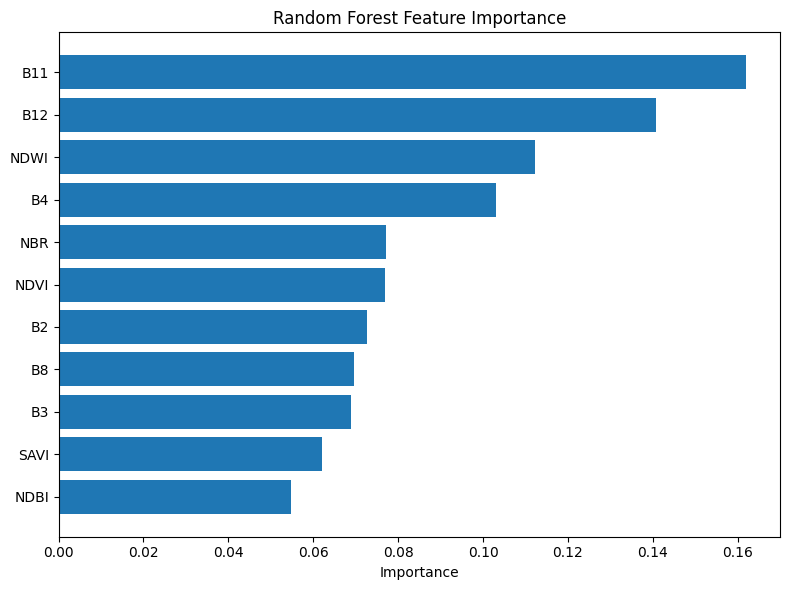

In [19]:
plt.figure(figsize=(8, 6))
plt.barh(fi["Feature"][::-1], fi["Importance"][::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rf_feature_importance.png"), dpi=200, bbox_inches="tight")
plt.show()

In [20]:
n_keep = max(3, int(np.ceil(len(feature_names_full) * 0.75)))
top_features = fi.head(n_keep)["Feature"].tolist()

feature_idx = [feature_names_full.index(f) for f in top_features]
Xf_train_reduced = Xf_train[:, feature_idx]
Xf_val_reduced = Xf_val[:, feature_idx]

rf_reduced = RandomForestClassifier(
    n_estimators=rf_best_n,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
res_reduced = fit_and_evaluate(rf_reduced, Xf_train_reduced, y_train, Xf_val_reduced, y_val, class_values, class_map)

feature_reduction_summary = pd.DataFrame([
    {"Model": f"RF full ({len(feature_names_full)} features)", "OA": rf_best_full["overall_accuracy"], "Kappa": rf_best_full["kappa"]},
    {"Model": f"RF reduced ({len(top_features)} features)", "OA": res_reduced["overall_accuracy"], "Kappa": res_reduced["kappa"]},
])

display(feature_reduction_summary.round(4))
feature_reduction_summary.to_csv(os.path.join(OUTPUT_DIR, "rf_feature_reduction_summary.csv"), index=False)
print("Features kept:", top_features)

,Model,OA,Kappa
0,RF full (11 features),0.9906,0.9518
1,RF reduced (9 features),0.9905,0.9518


Features kept: ['B11', 'B12', 'NDWI', 'B4', 'NBR', 'NDVI', 'B2', 'B8', 'B3']


## 📈 ขั้นที่ 8: ทดลองผลของจำนวน training samples

In [21]:
rng = np.random.default_rng(RANDOM_STATE)
train_idx = np.arange(len(y_train))
half_idx = rng.choice(train_idx, size=len(train_idx)//2, replace=False)

rf_half = RandomForestClassifier(
    n_estimators=rf_best_n,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
res_half = fit_and_evaluate(rf_half, Xf_train[half_idx], y_train[half_idx], Xf_val, y_val, class_values, class_map)

sample_size_summary = pd.DataFrame([
    {"Training_fraction": 0.5, "OA": res_half["overall_accuracy"], "Kappa": res_half["kappa"]},
    {"Training_fraction": 1.0, "OA": rf_best_full["overall_accuracy"], "Kappa": rf_best_full["kappa"]},
])
sample_size_summary["OA_gain_vs_50pct"] = sample_size_summary["OA"] - sample_size_summary.loc[sample_size_summary["Training_fraction"] == 0.5, "OA"].iloc[0]

display(sample_size_summary.round(4))
sample_size_summary.to_csv(os.path.join(OUTPUT_DIR, "training_fraction_comparison.csv"), index=False)

,Training_fraction,OA,Kappa,OA_gain_vs_50pct
0,0.5,0.9898,0.9479,0.0000
1,1.0,0.9906,0.9518,0.0007


## ❓ ขั้นที่ 9: หาคลาสที่สับสนกันมากที่สุด

In [22]:
cm_best = best_result["confusion_matrix"].copy()
cm_offdiag = cm_best.copy()
np.fill_diagonal(cm_offdiag, 0)

max_pair = np.unravel_index(np.argmax(cm_offdiag), cm_offdiag.shape)
ref_class = class_values[max_pair[0]]
pred_class = class_values[max_pair[1]]
max_confusion_count = int(cm_offdiag[max_pair])

print("Most confused pair:")
print("Reference :", class_map[ref_class])
print("Predicted :", class_map[pred_class])
print("Count     :", max_confusion_count)

Most confused pair:
Reference : Orchard
Predicted : Forest
Count     : 878


## 🗺️ ขั้นที่ 10: ทำนายเต็มพื้นที่แบบ tile / window เพื่อลดการใช้ RAM

In [23]:
def build_features_from_tile(tile_stack, base_band_names):
    """
    tile_stack shape = (bands, rows, cols)
    return feature_cube shape = (rows, cols, n_features)
    """
    arr = tile_stack.astype("float32")
    bdict = {name: arr[i] for i, name in enumerate(base_band_names)}

    green = bdict["B3"]
    red = bdict["B4"]
    nir = bdict["B8"]
    swir1 = bdict["B11"]
    swir2 = bdict["B12"]

    ndvi = safe_divide(nir - red, nir + red)
    ndwi = safe_divide(green - nir, green + nir)
    ndbi = safe_divide(swir1 - nir, swir1 + nir)
    savi = safe_divide((nir - red) * 1.5, nir + red + 0.5)
    nbr = safe_divide(nir - swir2, nir + swir2)

    base = np.transpose(arr, (1, 2, 0))
    full = np.dstack([base, ndvi, ndwi, ndbi, savi, nbr]).astype("float32")
    return full

In [24]:
rf_map_model = rf_best_full["model"]
rf_map_imp = rf_best_full["imputer"]

class_out = os.path.join(OUTPUT_DIR, "rf_classification_tiled.tif")
uncertainty_out = os.path.join(OUTPUT_DIR, "rf_uncertainty_tiled.tif")

with rasterio.open(RASTER_PATH) as src:
    meta_class = src.meta.copy()
    meta_class.update(count=1, dtype="uint16", nodata=0)

    meta_unc = src.meta.copy()
    meta_unc.update(count=1, dtype="float32", nodata=np.nan)

    with rasterio.open(class_out, "w", **meta_class) as dst_class, rasterio.open(uncertainty_out, "w", **meta_unc) as dst_unc:
        for _, window in src.block_windows(1):
            tile = src.read(selected_indexes, window=window)
            feat_tile = build_features_from_tile(tile, desired_band_names)

            n_rows, n_cols, n_feat = feat_tile.shape
            X_tile = feat_tile.reshape(-1, n_feat)
            X_tile = np.where(np.isfinite(X_tile), X_tile, np.nan)
            X_tile_imp = rf_map_imp.transform(X_tile)

            valid_mask = np.any(X_tile_imp[:, :len(desired_band_names)] != 0, axis=1)

            pred = np.zeros(X_tile_imp.shape[0], dtype="uint16")
            unc = np.full(X_tile_imp.shape[0], np.nan, dtype="float32")

            if valid_mask.sum() > 0:
                pred_valid = rf_map_model.predict(X_tile_imp[valid_mask])
                prob_valid = rf_map_model.predict_proba(X_tile_imp[valid_mask]).astype("float32")
                pred[valid_mask] = pred_valid.astype("uint16")
                unc[valid_mask] = 1.0 - prob_valid.max(axis=1)

            pred = pred.reshape(n_rows, n_cols)
            unc = unc.reshape(n_rows, n_cols)

            dst_class.write(pred, 1, window=window)
            dst_unc.write(unc, 1, window=window)

print("Saved tiled outputs:")
print(class_out)
print(uncertainty_out)

Saved tiled outputs:
/content/drive/MyDrive/Lab3_Data/NKNY/outputs_lab3_fixed/rf_classification_tiled.tif
/content/drive/MyDrive/Lab3_Data/NKNY/outputs_lab3_fixed/rf_uncertainty_tiled.tif


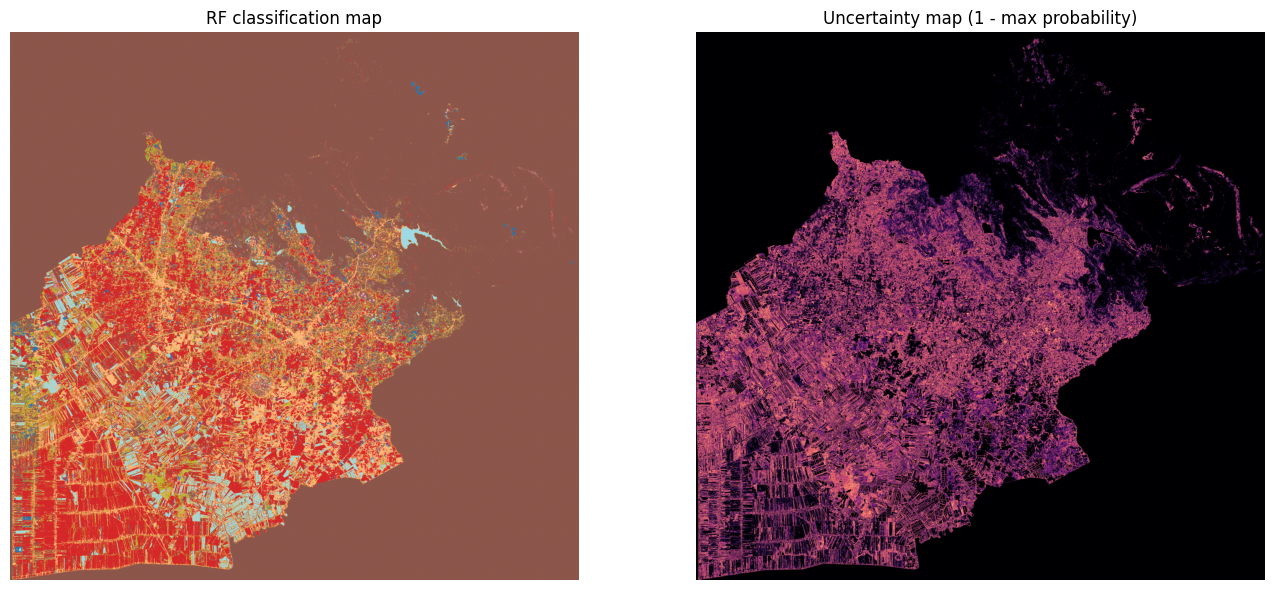

In [25]:
with rasterio.open(class_out) as src:
    class_map_preview = src.read(1)

with rasterio.open(uncertainty_out) as src:
    unc_preview = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(class_map_preview, cmap="tab20")
axes[0].set_title("RF classification map")
axes[1].imshow(unc_preview, cmap="magma")
axes[1].set_title("Uncertainty map (1 - max probability)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "classification_and_uncertainty_preview.png"), dpi=200, bbox_inches="tight")
plt.show()

## 🧾 ขั้นที่ 11: สรุปเชิงความเรียงสำหรับเอาไปใช้ใน README

In [26]:
best_per_class = best_result["per_class"].copy()
worst_class = best_per_class.sort_values("F1_score").iloc[0]
best_feature = fi.iloc[0]["Feature"]
best_feature_score = fi.iloc[0]["Importance"]

summary_lines = []
summary_lines.append("# Lab 3 summary draft")
summary_lines.append("")
summary_lines.append("## 1) Training strategy")
summary_lines.append(
    f"งานนี้ใช้ข้อมูลฝึกสอนแบบ polygon ในพื้นที่จังหวัดนครนายกทั้งหมด {len(gdf)} polygon และคงไว้ {len(class_values)} คลาส ได้แก่ " +
    ", ".join([class_map[c] for c in class_values]) + "."
)
summary_lines.append(
    "การแบ่งชุดข้อมูลใช้การสุ่มแบบ stratified 80/20 เพื่อให้ทุกคลาสยังคงสัดส่วนใกล้เคียงเดิมในชุด train และ validation แต่ต้องยอมรับว่าการสุ่มแบบนี้อาจให้ค่าความแม่นยำสูงกว่าความเป็นจริงเล็กน้อยจาก spatial autocorrelation."
)
summary_lines.append("")
summary_lines.append("## 2) Algorithm comparison")
summary_lines.append(
    f"โมเดลที่ให้ผลดีที่สุดในรอบนี้คือ {best_row['Model']} ภายใต้ชุด feature แบบ {best_row['Features']} โดยมี Overall Accuracy = {best_result['overall_accuracy']:.4f} และ Kappa = {best_result['kappa']:.4f}."
)
summary_lines.append("")
summary_lines.append("## 3) Feature importance")
summary_lines.append(
    f"ตัวแปรที่สำคัญที่สุดของ Random Forest คือ {best_feature} (importance = {best_feature_score:.6f}) ซึ่งควรตีความร่วมกับลักษณะทางกายภาพของคลาสในพื้นที่."
)
summary_lines.append("")
summary_lines.append("## 4) Weak class and uncertainty")
summary_lines.append(
    f"คลาสที่ทำได้แย่ที่สุดจาก F1-score คือ {worst_class['Classname']} (F1 = {worst_class['F1_score']:.4f})."
)
summary_lines.append(
    f"คู่คลาสที่สับสนกันมากที่สุดคือ reference = {class_map[ref_class]} และ predicted = {class_map[pred_class]} จำนวน {max_confusion_count} จุด/pixel ในชุด validation."
)
summary_lines.append("")
summary_lines.append("## 5) Effect of more training samples")
summary_lines.append(
    f"เมื่อเปรียบเทียบการใช้ข้อมูล train เพียง 50% กับ 100% พบว่า OA เปลี่ยนจาก {res_half['overall_accuracy']:.4f} เป็น {rf_best_full['overall_accuracy']:.4f}."
)

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(os.path.join(OUTPUT_DIR, "lab3_summary_draft.md"), "w", encoding="utf-8") as f:
    f.write(summary_text)

# Lab 3 summary draft

## 1) Training strategy
งานนี้ใช้ข้อมูลฝึกสอนแบบ polygon ในพื้นที่จังหวัดนครนายกทั้งหมด 7 polygon และคงไว้ 7 คลาส ได้แก่ Bareland, Buildup, Fieldcrop, Forest, Orchard, Perennial, Water.
การแบ่งชุดข้อมูลใช้การสุ่มแบบ stratified 80/20 เพื่อให้ทุกคลาสยังคงสัดส่วนใกล้เคียงเดิมในชุด train และ validation แต่ต้องยอมรับว่าการสุ่มแบบนี้อาจให้ค่าความแม่นยำสูงกว่าความเป็นจริงเล็กน้อยจาก spatial autocorrelation.

## 2) Algorithm comparison
โมเดลที่ให้ผลดีที่สุดในรอบนี้คือ RandomForest ภายใต้ชุด feature แบบ Bands only โดยมี Overall Accuracy = 0.9910 และ Kappa = 0.9539.

## 3) Feature importance
ตัวแปรที่สำคัญที่สุดของ Random Forest คือ B11 (importance = 0.161884) ซึ่งควรตีความร่วมกับลักษณะทางกายภาพของคลาสในพื้นที่.

## 4) Weak class and uncertainty
คลาสที่ทำได้แย่ที่สุดจาก F1-score คือ Orchard (F1 = 0.3005).
คู่คลาสที่สับสนกันมากที่สุดคือ reference = Orchard และ predicted = Forest จำนวน 878 จุด/pixel ในชุด validation.

## 5) Effect of more training samples
เมื่อเปรียบเทียบการ

## ✅ ข้อควรเขียนใน README หลังจากรันเสร็จ

เมื่อคุณรัน notebook นี้จนจบแล้ว ให้ดึงผลจากตารางและรูปไปอธิบายเป็นความเรียง โดยตอบประเด็นเหล่านี้ให้ครบตามโจทย์ Lab 3

1. ทำไมถึงเลือก 7 คลาส และนิยามแต่ละคลาสว่าอะไร  
2. ใช้วิธีสร้าง training samples แบบใด และมีข้อจำกัดอะไร  
3. Random split 80/20 ให้ข้อดีอะไร และ spatial CV ต่างอย่างไร  
4. Bands only กับ bands + indices ต่างกันมากน้อยแค่ไหน  
5. โมเดลไหนดีที่สุด และเพราะอะไร  
6. Feature ใดสำคัญที่สุด และสอดคล้องกับกายภาพของพื้นที่หรือไม่  
7. เมื่อตัด feature สำคัญต่ำออก ความแม่นยำเปลี่ยนอย่างไร  
8. คลาสใดสับสนกันมากที่สุด และเพราะอะไร  
9. บริเวณ uncertainty สูงอยู่ตรงไหน และควรอธิบายกับ stakeholder อย่างไร  
10. หากเพิ่ม training samples หรือย้ายไปพื้นที่อื่น ต้องปรับอะไรบ้าง